<a href="https://colab.research.google.com/github/Imase0606/AI-Project-Train/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# 读取训练集数据
df = pd.read_csv('train.csv')

# 召唤出表格的前 5 行（注意不要加 print）
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# 1. 查看整张表的数据健康状况（关注 Non-Null Count 和 Dtype）
print("--- 原始数据体检报告 ---")
df.info()

# 2. 特征工程第一步：把性别字符串变成数字 (0和1)
# 机器不懂 male/female，但懂 0 和 1
df['Sex'] = df['Sex'].map({'female': 1, 'male': 0})

# 3. 再看一眼转换后的前5行数据
print("\n--- 清洗性别后的数据前 5 行 ---")
df[['Name', 'Sex']].head()

--- 原始数据体检报告 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- 清洗性别后的数据前 5 行 ---


,Name,Sex
0,"Braund, Mr. Owen Harris",0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1
2,"Heikkinen, Miss. Laina",1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
4,"Allen, Mr. William Henry",0


In [4]:
# 1. 策略一：填补 (Imputation)
# 计算已知年龄的中位数 (大概是 28 岁)，并填补给那些缺失的人
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

# 寻找最多人登船的港口 (众数)，填补那 2 个缺失值
# mode()[0] 就是找出出现次数最多的那个值
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

# 2. 策略二：舍弃 (Drop)
# 船舱缺失太多、船票全是乱码、乘客ID对预测没用，统统删掉！
columns_to_drop = ['Cabin', 'Ticket', 'PassengerId']
df = df.drop(columns=columns_to_drop)

# 3. 再次进行全身体检！
print("--- 手术后的数据健康状况 ---")
df.info()

--- 手术后的数据健康状况 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    int64  
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  891 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


In [5]:
# 1. 忍痛割爱：第一版基础模型先不处理复杂的姓名，直接删掉
df = df.drop(columns=['Name'])

# 2. 独热编码 (One-Hot Encoding) 的魔法
# 将 Embarked 一列裂变成三列纯数字 (0和1)
df = pd.get_dummies(df, columns=['Embarked'], dtype=int)

# 3. 见证奇迹的时刻：查看最终完全由纯数字组成的终极矩阵！
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. 切分特征 (X) 和 目标答案 (y)
y = df['Survived']
X = df.drop(columns=['Survived'])

# 2. 划分训练集和测试集 (80%用来学习，20%用来考试)
# random_state=42 是为了保证每次随机抽题的结果都一样，方便我们复现
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 召唤模型：设定一棵最大深度为 3 的决策树
# 限制深度是为了防止它“死记硬背”每一个乘客，导致泛化能力变差
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# 4. 开始训练！(用 fit 函数让模型在训练集上拟合数据)
print("🧠 决策树正在疯狂学习中...")
tree_model.fit(X_train, y_train)

# 5. 期末考试 (在没见过的 X_test 上进行预测)
predictions = tree_model.predict(X_test)

# 6. 对答案，算分数
score = accuracy_score(y_test, predictions)
print(f"🎉 考试结束！模型在未知数据上的准确率为: {score * 100:.2f}%")

🧠 决策树正在疯狂学习中...
🎉 考试结束！模型在未知数据上的准确率为: 79.89%


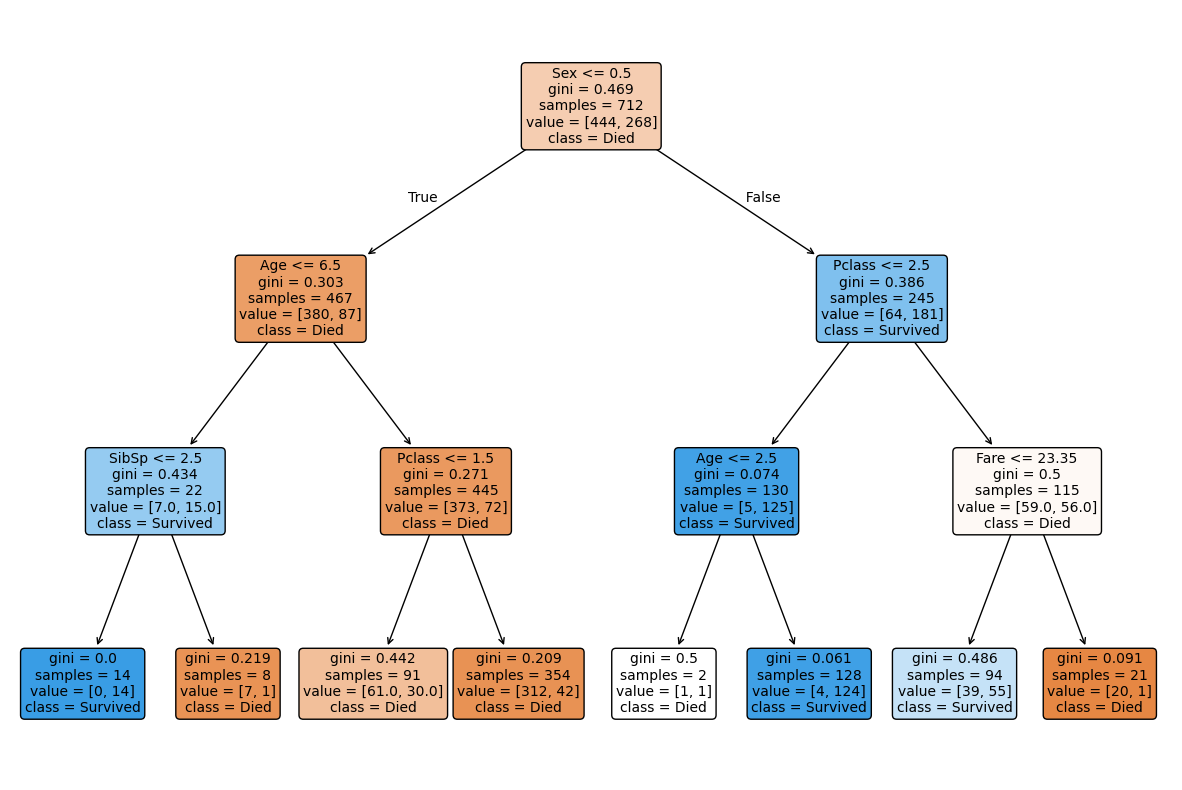

In [7]:
import matplotlib.pyplot as plt
from sklearn import tree

# 设置画布大小
plt.figure(figsize=(15, 10))

# 画出决策树
tree.plot_tree(tree_model,
               feature_names=X.columns, # 告诉它每一列特征的名字
               class_names=['Died', 'Survived'], # 0 是遇难，1 是生还
               filled=True, # 给不同结果上色，越纯的节点颜色越深
               rounded=True,
               fontsize=10)

plt.show()

In [8]:
import pandas as pd
import joblib # 用于保存模型的超强工具
from sklearn.linear_model import LogisticRegression

# ================= 1. 准备课本 (训练集) =================
# 假设 df 已经是我们刚才清洗好、get_dummies 裂变完的完美训练集
X_train = df.drop(columns=['Survived'])
y_train = df['Survived']

# 召唤逻辑回归模型，并让它在所有训练数据上疯狂学习
# max_iter=1000 是为了防止数据没收敛而报错
lr_model = LogisticRegression(max_iter=1000, random_state=42)
print("🧠 逻辑回归模型正在计算各项特征权重...")
lr_model.fit(X_train, y_train)

# ================= 2. 固化大脑 (保存模型) =================
# 把训练好的模型保存为一个实体文件，以后做 H5 网页就能直接加载它了！
joblib.dump(lr_model, 'titanic_lr_model.pkl')
print("💾 模型已成功保存为 titanic_lr_model.pkl！")

# ================= 3. 拆开期末考卷 (读取并清洗 test.csv) =================
# 注意：提前确保你已经把 test.csv 放进了同级目录
test_df = pd.read_csv('test.csv')

# 把乘客的学号 (PassengerId) 先单独保管好，交卷要用
passenger_ids = test_df['PassengerId']

# 开始执行和之前一模一样的手术
# (1) 映射性别
test_df['Sex'] = test_df['Sex'].map({'female': 1, 'male': 0})
# (2) 填补年龄和票价 (使用训练集的中位数更严谨，但这里简化直接用测试集自身的也可以)
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
# (3) 删掉没用的垃圾特征 (Ticket, Cabin, Name, 以及已经被抽出来的 PassengerId)
test_df = test_df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
# (4) 港口裂变 (One-Hot)
test_df = pd.get_dummies(test_df, columns=['Embarked'], dtype=int)

# 【极度重要的一步】：确保考卷的列和课本的列完全对齐！
# 如果测试集里刚好没人从 Q 港口上车，少了一列，模型就会崩溃
# 这行代码会强行让 test_df 的列名和顺序与 X_train 完全一致，缺的补0
X_test = test_df.reindex(columns=X_train.columns, fill_value=0)

# ================= 4. 蒙眼答题，生成提交文件 =================
print("✍️ 模型正在为测试集的乘客算命...")
predictions = lr_model.predict(X_test)

# 按照 Kaggle 要求的 gender_submission.csv 格式，拼装出我们自己的答题卡
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': predictions
})

# 导出为 csv 文件
submission.to_csv('my_first_submission.csv', index=False)
print("🎉 大功告成！预测结果已保存为 my_first_submission.csv")

🧠 逻辑回归模型正在计算各项特征权重...
💾 模型已成功保存为 titanic_lr_model.pkl！
✍️ 模型正在为测试集的乘客算命...
🎉 大功告成！预测结果已保存为 my_first_submission.csv
